# Bidirectional predictive coding

This notebook demonstrates how a predictive coding network can be extended with bidirectional connections. A single model simultaneously learns a bottom-up **recognition** path (image → label) and a top-down **generative** path (label → image) by sharing latent `PCLayer()` variables between the two directions.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bogacz-Group/PredictiveCoding/blob/main/5_bidirectional_pc.ipynb)


In [33]:
# import pc library if the code is being run on google colab
try:
  import google.colab
  !git clone https://github.com/Bogacz-Group/PredictiveCoding.git
  ! cp -r PredictiveCoding/predictive_coding predictive_coding
except ImportError:
  pass


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import predictive_coding as pc

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'using {device}')


using cuda


### Load data


In [35]:
# data
n_train = 10000
n_val = 500
n_test = 1000

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: torch.flatten(x))])
dataset_train = datasets.MNIST('./data', download=True, train=True, transform=transform)
dataset_eval = datasets.MNIST('./data', download=True, train=False, transform=transform)

# randomly sample train and evaluation subsets
train_dataset = torch.utils.data.Subset(dataset_train, random.sample(range(len(dataset_train)), n_train))
val_dataset, test_dataset, _ = torch.utils.data.random_split(dataset_eval, [n_val, n_test, len(dataset_eval) - n_val - n_test])

print(f'# train: {len(train_dataset)}, # val: {len(val_dataset)}, # test: {len(test_dataset)}')


# train: 10000, # val: 500, # test: 1000


### Defining a bidirectional model

In a standard predictive coding network, predictions flow in a single direction (bottom-up). In a **bidirectional model**, two pathways share the same `PCLayer()` latent layers:

- The **bottom-up (recognition) path** maps an image to a class label.
- The **top-down (generative) path** maps a class label back to an image.

Because the two paths share the same `PCLayer()` objects, their prediction errors are combined. The shared latent states are therefore optimised jointly under both upward and downward constraints, coupling recognition and generation in a single network.

The `test()` function evaluates classification accuracy by running only the bottom-up path.


In [36]:
class BidirectionalPC(nn.Module):
    def __init__(self, alpha_up=1., alpha_down=1., pc_energy_fn=None, sample_fn=None):
        super(BidirectionalPC, self).__init__()
        
        if pc_energy_fn is None:
            pc_energy_fn =  lambda inputs: 0.5 *(inputs['mu'] - inputs['x'])**2
        
        if sample_fn is None:
            sample_fn = lambda inputs: inputs['mu'].detach().clone()


        # pc layer shared by up and down model
        self.pcs = [
            pc.PCLayer(energy_fn=pc_energy_fn, sample_x_fn=sample_fn),
            pc.PCLayer(energy_fn=pc_energy_fn, sample_x_fn=sample_fn)
        ]
        
        self.activation = nn.ReLU()

        # up model
        self.model_up = nn.Sequential(
            nn.Linear(784, 256),
            self.pcs[0],
            self.activation,
            nn.Linear(256, 256),
            self.pcs[1],
            self.activation,
            nn.Linear(256, 10),
        )
        # down model
        self.model_down = nn.Sequential(
            nn.Linear(10, 256),
            self.pcs[1],
            self.activation,
            nn.Linear(256, 256),
            self.pcs[0],
            self.activation,
            nn.Linear(256, 784),
        )

        self._alpha_up = alpha_up
        self._alpha_down = alpha_down
    
    def get_energies(self):
        return [pc._energy.clone() for pc in self.pcs]

    def set_energies(self, energies):
        for i, energy in enumerate(energies):
            self.pcs[i]._energy = energy

    def forward(self, input):
        x = input[0]    # image
        y = input[1]    # label
        # get energies for up (this also initialises the latent layers)
        out_up = self.model_up(x)
        energy_up = self.get_energies()
        # get energies for down 
        out_down = self.model_down(y)
        energy_down = self.get_energies()
        # add the energies of the up and down model
        energy = [self._alpha_down*e_down + self._alpha_up*e_up  for (e_up, e_down) in zip(energy_up, energy_down)]
        self.set_energies(energy)
        return out_up, out_down


def test(model, dataset, batch_size=1000):
    model.eval()
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    for data, label in test_loader:
        data, label = data.to(device), label.to(device)
        pred = model.model_up(data)
        _, predicted = torch.max(pred, -1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
    model.train()
    return round(correct / total, 4)

### Model and loss setup

`alpha_up` and `alpha_down` control the relative contribution of each pathway to the total energy. Setting `alpha_down` very small allows the model to learn primarily as a classifier while still training the generative path.

The loss function combines the supervised classification error (bottom-up) and the reconstruction error (top-down), each scaled by its respective alpha.


In [37]:
alpha_up = 1.0  # scaling factor of the up model
alpha_down = 0.0001    # scaling factor of the down model

# get model
model = BidirectionalPC(alpha_down=alpha_down, alpha_up=alpha_up)
model.train()
model.to(device)


# loss function
mse = nn.MSELoss(reduction="sum")
def loss_fn(output , _target_up, _target_down):
    output_up, output_down = output
    error_up = mse(output_up, _target_up)*alpha_up
    error_down = mse(output_down, _target_down)*alpha_down
    return error_up + error_down

### Defining a model trainer

The `pc.PCTrainer()` is set up in the same way as for a standard model. The trainer alternates between updating the latent states `x` (inference) and updating the parameters `p` (learning) to minimise the combined energy of both pathways.


In [38]:
T = 20                             # number of inference iterations
update_x_at = 'all'                 # update latent state x at every iteration
optimizer_x_fn = optim.SGD         # optimizer for latent state x
optimizer_x_kwargs = {'lr': 0.01}    # optimizer parameters for latent state x
update_p_at = 'last'                # update parameters p at the last iteration
optimizer_p_fn = optim.Adam          # optimizer for parameters p
optimizer_p_kwargs = {"lr": 1e-2, "weight_decay":0.} # optimizer parameters for parameters p
plot_progress_at = []            # plot progress every inference iterations

trainer = pc.PCTrainer(model, 
    T = T, 
    update_x_at = update_x_at, 
    optimizer_x_fn = optimizer_x_fn,
    optimizer_x_kwargs = optimizer_x_kwargs,
    update_p_at = update_p_at,   
    optimizer_p_fn = optimizer_p_fn,
    optimizer_p_kwargs = optimizer_p_kwargs,
    plot_progress_at= plot_progress_at
)

### Train the model

`trainer.train_on_batch()` receives a tuple `(image, label)` as input. For each batch, the bottom-up and top-down energies are computed and combined before the latent states and parameters are updated.


Epoch 10 - Val accuracy: 0.958: 100%|██████████| 20/20 [00:03<00:00,  6.56it/s]


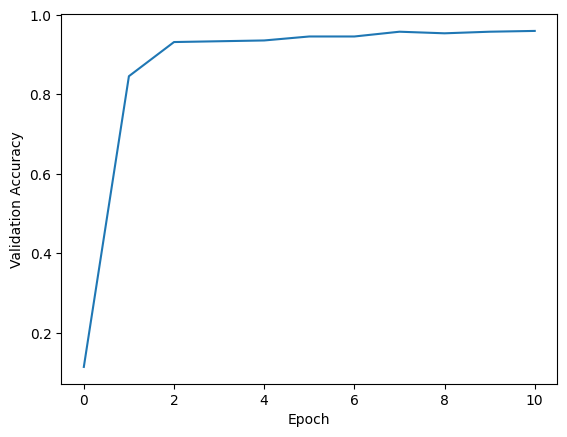

Test accuracy: 0.961


In [39]:
epochs = 10
batch_size = 500
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_acc = np.zeros(epochs + 1)
val_acc[0] = test(model, val_dataset)
model.train()
for epoch in range(epochs):
    with tqdm(train_loader, desc=f'Epoch {epoch+1} - Val accuracy: {val_acc[epoch]:.3f}') as pbar:
        for data, label in pbar:
            data, label = data.to(device), label.to(device)
            labels_one_hot = F.one_hot(label, num_classes=10).float()
            inputs = (data, labels_one_hot)
            loss_fn_kwargs = {"_target_up": labels_one_hot, "_target_down": data}
            trainer.train_on_batch(inputs=inputs, loss_fn=loss_fn, loss_fn_kwargs=loss_fn_kwargs, is_log_progress=False, is_return_results_every_t=False, is_checking_after_callback_after_t=False)
    val_acc[epoch + 1] = test(model, val_dataset)
    pbar.set_description(f'Epoch {epoch+1} - Val accuracy: {val_acc[epoch+1]:.3f}')

plt.plot(val_acc)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.show()
print(f"Test accuracy: {test(model, test_dataset)}")


### Generate images from class labels

Once trained, the generative (top-down) path can be used to synthesise images by passing a one-hot class label through `model.model_down`. This demonstrates that the shared latent layers have learned a meaningful generative representation alongside the classifier.


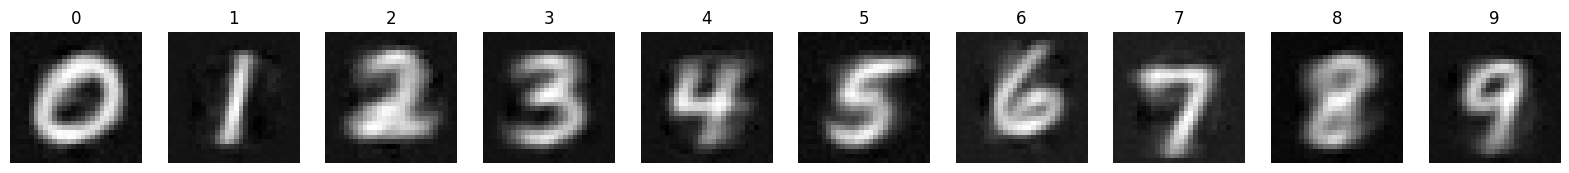

In [40]:
# generate images
model.eval()

imgs = []
for i in (range(10)):
    input = torch.zeros(1, 10)
    input[0, i] = 1
    input = input.to(device)

    img = model.model_down(input)
    imgs.append(img.cpu().detach().sigmoid().numpy().reshape(28, 28))

# show 10 images one for each digit
fig, ax = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    ax[i].imshow(imgs[i], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'{i}')

plt.show()

The generated images show recognisable digit shapes for each class, confirming that the shared latent layers have learned a generative representation. The model achieves competitive classification accuracy, comparable to a standard bottom-up predictive coding network trained on MNIST, while simultaneously learning to generate images.
